In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize'   : (9, 5),
    'figure.dpi'       : 120,
    'axes.titlesize'   : 14,
    'axes.titlepad'    : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'ytick.labelsize'  : 10,
    'xtick.labelsize'  : 10,
})
data = r'D:\Unsupervised_lab\retail-unsupervised-lab\data\Online Retail - Online Retail.csv'
df = pd.read_csv(data)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


# DATA UNDERSTANDING

In [2]:
print(f'Shape : {df.shape[0]} rows x {df.shape[1]} columns')
print('Columns :')
print(df.dtypes.to_string())

Shape : 541909 rows x 8 columns
Columns :
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [5]:
Purchase_by_country = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)
Purchase_by_country.head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: InvoiceNo, dtype: int64

# DATA CLEANING

In [6]:
dup_counts = df.duplicated().sum()
if dup_counts > 0:
    df = df.drop_duplicates()
    print(f'Duplicates Removed. New Shape : {df.shape}')
else:
    print('No Duplicates , Dataset Is Clean.')

Duplicates Removed. New Shape : (536641, 8)


In [7]:
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_pct}).sort_values(by='Missing Values', ascending=False)
print(missing_data.to_string())

             Missing Values  Percentage
CustomerID           135037   25.163377
Description            1454    0.270945
StockCode                 0    0.000000
InvoiceNo                 0    0.000000
Quantity                  0    0.000000
InvoiceDate               0    0.000000
UnitPrice                 0    0.000000
Country                   0    0.000000


In [8]:
before = len(df)
df   = df.dropna(subset=['CustomerID'])
after  = len(df)
print(f'Rows removed (no CustomerID): {before - after}')
print(f'Remaining rows              : {after}')

Rows removed (no CustomerID): 135037
Remaining rows              : 401604


In [9]:
before = len(df)
df   = df[df['Quantity']  > 0]
df   = df[df['UnitPrice'] > 0]
after  = len(df)
print(f'Invalid transactions removed : {before - after}')
print(f'Remaining rows               : {after}')

Invalid transactions removed : 8912
Remaining rows               : 392692


In [10]:
num_cols = ['Quantity', 'UnitPrice']
outliers_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Count': len(outliers),
        'Outliers Percentage': (len(outliers) / len(df)) * 100
    })
outliers_df = pd.DataFrame(outliers_summary)
print(outliers_df.to_string())
print(f'\ntotal outliers detected : {outliers_df["Outliers Count"].sum()}')

      Column  Lower Bound  Upper Bound  Outliers Count  Outliers Percentage
0   Quantity        -13.0         27.0           25616             6.523178
1  UnitPrice         -2.5          7.5           34112             8.686706

total outliers detected : 59728


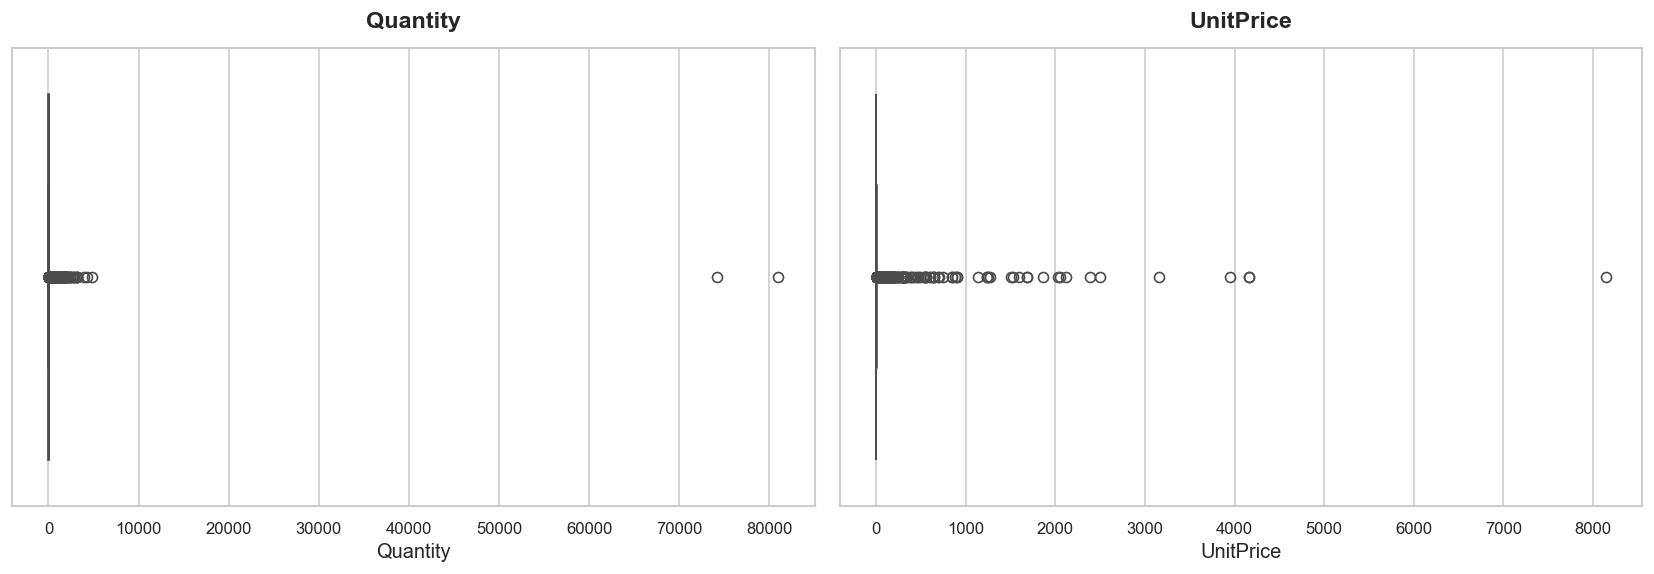

In [11]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Feature Engineering — RFM Calculation

In [12]:
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# Reference date = 1 day after the last invoice in the dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalSpend',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f'RFM table shape: {rfm.shape[0]} customers x {rfm.shape[1]} columns')
rfm.head(10)

RFM table shape: 4338 customers x 4 columns


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


## EDA (Exploratory Data Analysis)

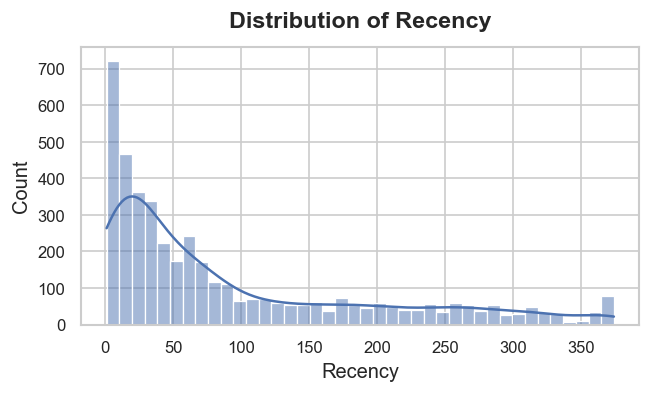

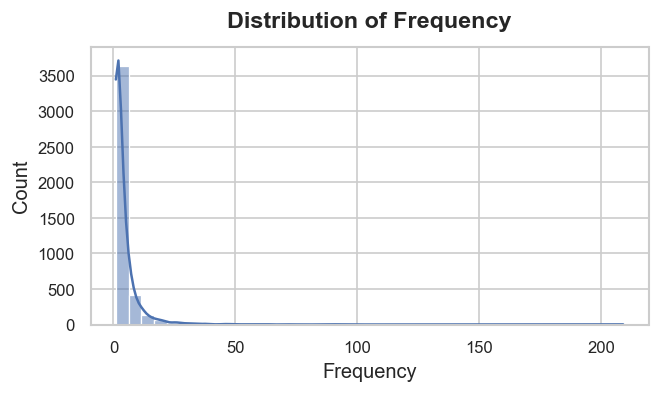

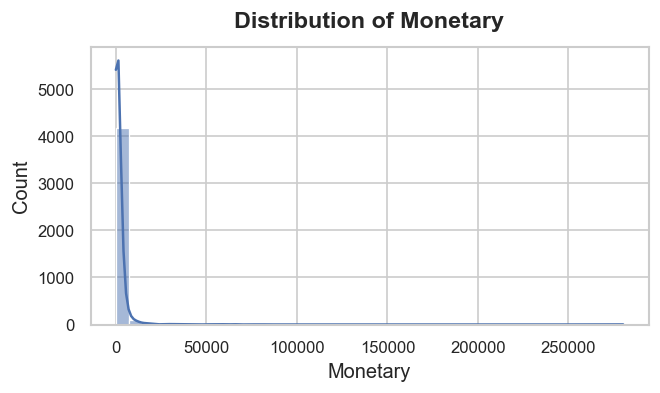

In [13]:
rfm_cols = ['Recency', 'Frequency', 'Monetary']

for col in rfm_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(rfm[col], kde=True, bins=40)
    plt.title(f'Distribution of {col}')
    plt.show()

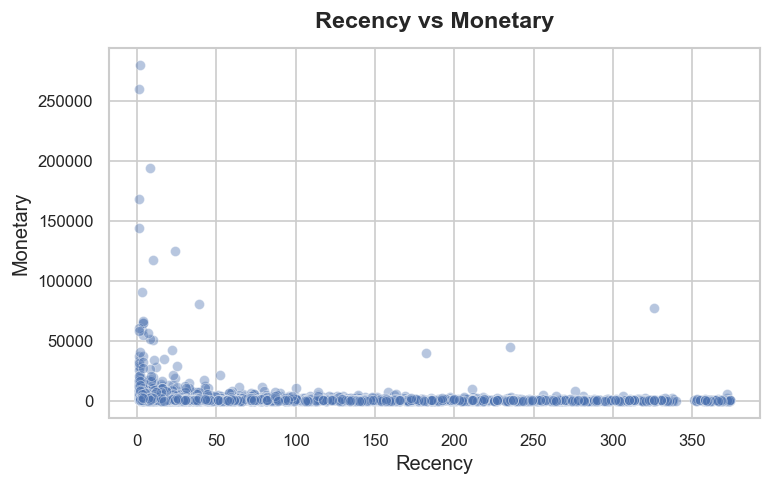

In [14]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Recency', y='Monetary', data=rfm, alpha=0.4)
plt.title('Recency vs Monetary')
plt.show()

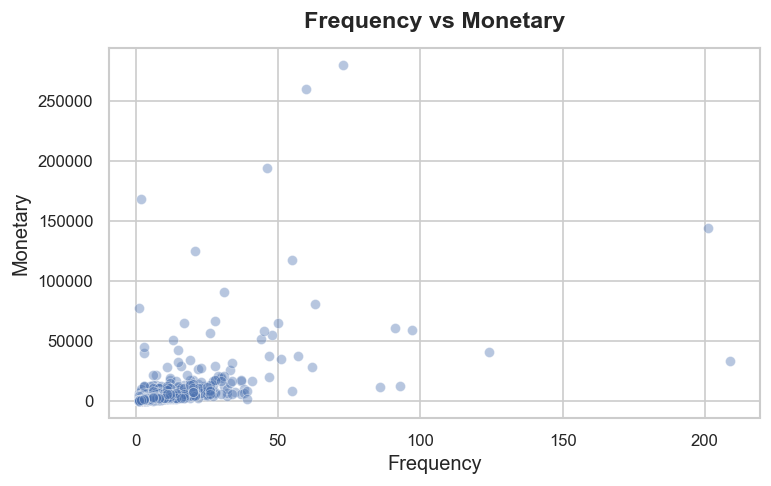

In [15]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Frequency', y='Monetary', data=rfm, alpha=0.4)
plt.title('Frequency vs Monetary')
plt.show()


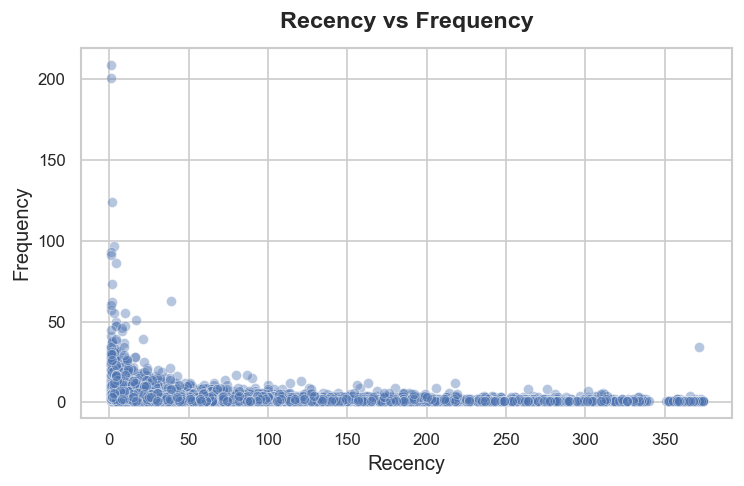

In [16]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Recency', y='Frequency', data=rfm, alpha=0.4)
plt.title('Recency vs Frequency')
plt.show()

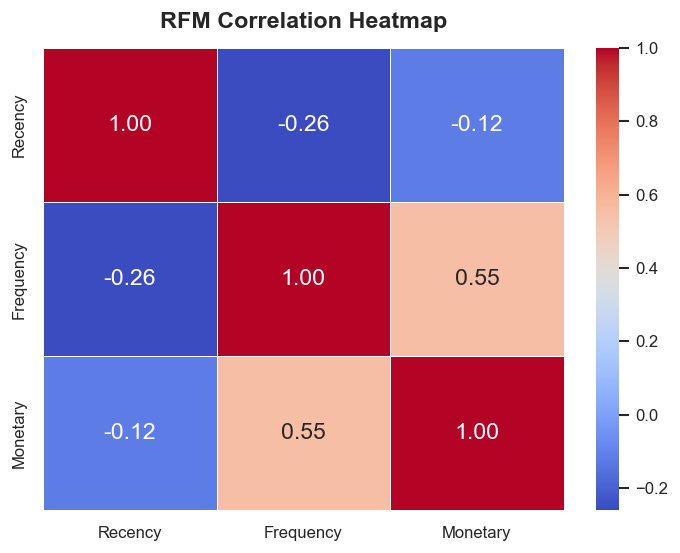

In [17]:
plt.figure(figsize=(7, 5))
corr = rfm[rfm_cols].corr()
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('RFM Correlation Heatmap')
plt.show()

## preprocessing


In [18]:
rfm_log = rfm.copy()
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])

print('RFM after Log Transformation:')
rfm_log[rfm_cols].describe().round(3)

RFM after Log Transformation:


,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,3.831,1.346,6.589
std,1.340,0.683,1.258
min,0.693,0.693,1.558
25%,2.944,0.693,5.728
50%,3.951,1.099,6.507
75%,4.963,1.792,7.416
max,5.927,5.347,12.543


In [19]:
scaler    = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[rfm_cols])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_cols)

print('RFM after Scaling:')
rfm_scaled.describe().round(3)


RFM after Scaling:


,Recency,Frequency,Monetary
count,4338.000,4338.000,4338.000
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000
min,-2.341,-0.955,-3.998
25%,-0.661,-0.955,-0.684
50%,0.090,-0.362,-0.065
75%,0.845,0.653,0.657
max,1.564,5.859,4.732


## Finding Optimal Number of Clusters


Elbow Method


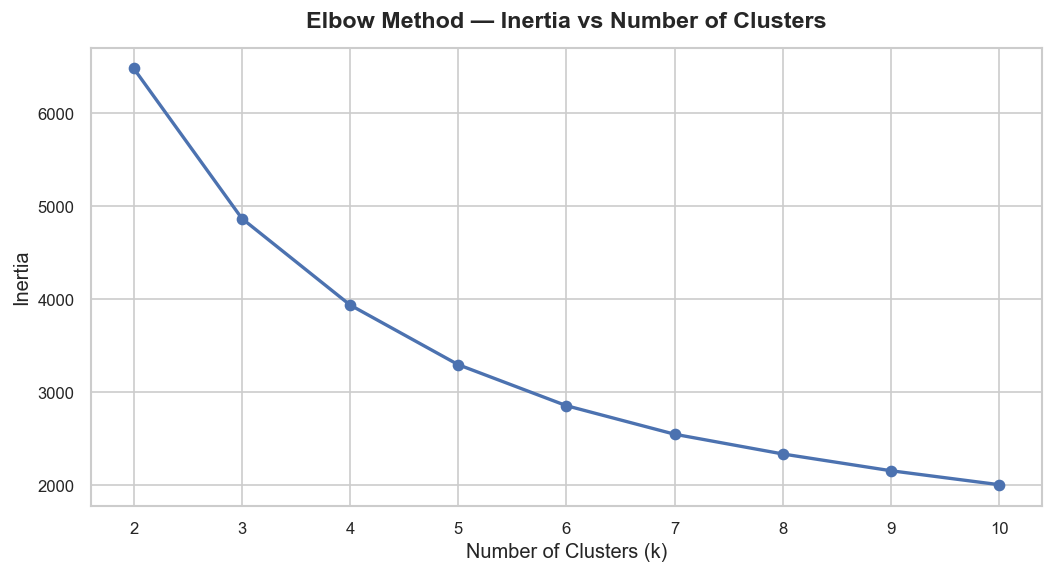

In [20]:
k_range  = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2)
plt.title('Elbow Method — Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

Silhoute Score

In [21]:
sil_scores = []
db_scores  = []
ch_scores  = []

for k in k_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(rfm_scaled)
    sil_scores.append(silhouette_score(rfm_scaled, labels))
    db_scores.append(davies_bouldin_score(rfm_scaled, labels))
    ch_scores.append(calinski_harabasz_score(rfm_scaled, labels))

metrics_df = pd.DataFrame({
    'k'                  : list(k_range),
    'Silhouette Score'   : [round(s, 4) for s in sil_scores],
    'Davies-Bouldin'     : [round(d, 4) for d in db_scores],
    'Calinski-Harabasz'  : [round(c, 2) for c in ch_scores]
})
print(metrics_df.to_string(index=False))

 k  Silhouette Score  Davies-Bouldin  Calinski-Harabasz
 2            0.4328          0.8925            4367.32
 3            0.3365          1.0483            3625.30
 4            0.3375          1.0086            3328.34
 5            0.3162          0.9878            3192.98
 6            0.3124          1.0210            3081.89
 7            0.3092          0.9823            2963.79
 8            0.3033          0.9892            2827.07
 9            0.2811          1.0193            2725.20
10            0.2767          1.0268            2639.29


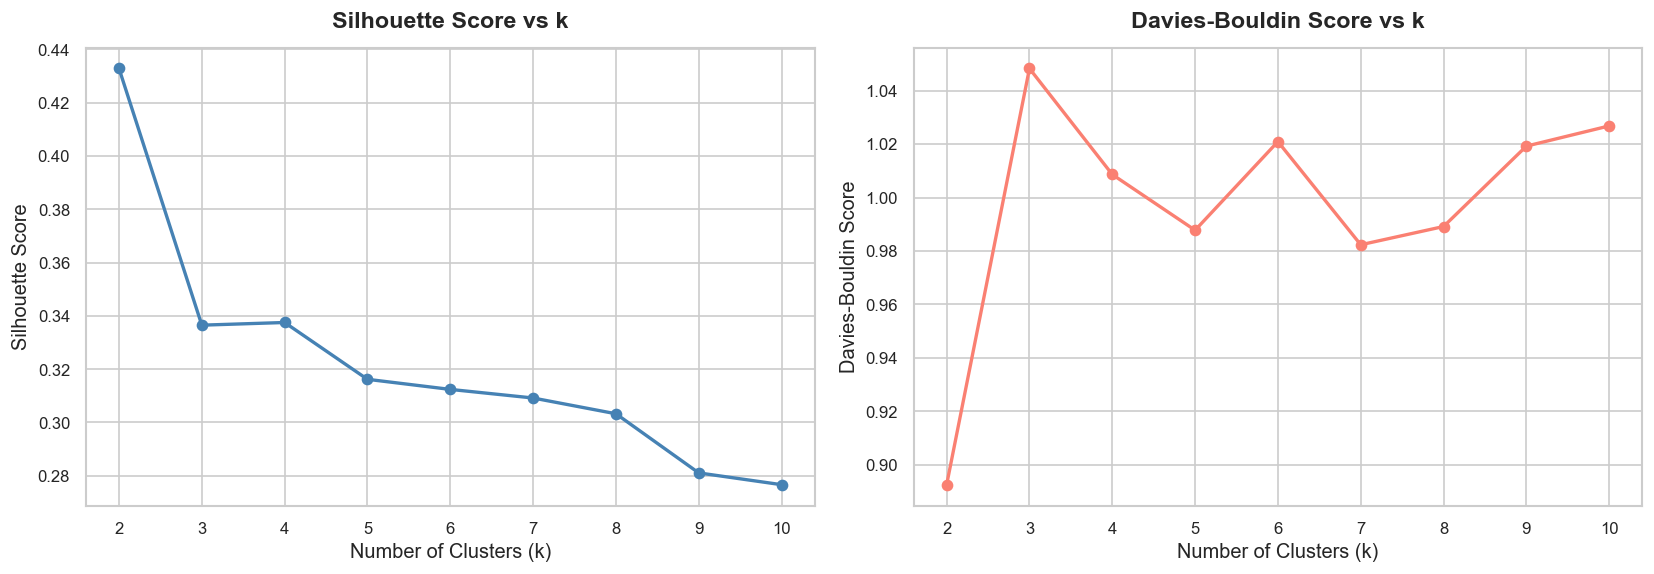

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, sil_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, db_scores, marker='o', color='salmon', linewidth=2)
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

## Model Building K-Means Clusters

In [30]:
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f'Customers per cluster (k={k}):')
print(rfm['Cluster'].value_counts().sort_index().to_string())


Customers per cluster (k=4):
Cluster
0     713
1    1622
2     837
3    1166


model Evaluation


In [31]:
labels = rfm['Cluster']

sil = silhouette_score(rfm_scaled, labels)
db  = davies_bouldin_score(rfm_scaled, labels)
ch  = calinski_harabasz_score(rfm_scaled, labels)

print(f'Silhouette Score    : {sil:.4f}  (higher = better, max = 1.0)')
print(f'Davies-Bouldin Score: {db:.4f}  (lower  = better)')
print(f'Calinski-Harabasz   : {ch:.2f}   (higher = better)')


Silhouette Score    : 0.3375  (higher = better, max = 1.0)
Davies-Bouldin Score: 1.0086  (lower  = better)
Calinski-Harabasz   : 3328.34   (higher = better)


In [32]:
cluster_profile = rfm.groupby('Cluster')[rfm_cols].mean().round(2)
cluster_profile['Size'] = rfm.groupby('Cluster').size()
cluster_profile['Size %'] = (cluster_profile['Size'] / len(rfm) * 100).round(1)
print(cluster_profile.to_string())

         Recency  Frequency  Monetary  Size  Size %
Cluster                                            
0          12.17      13.75   8088.02   713    16.4
1         181.51       1.32    341.00  1622    37.4
2          17.70       2.19    557.32   837    19.3
3          71.64       4.08   1801.78  1166    26.9


In [33]:
profile = rfm.groupby('Cluster')[rfm_cols].mean()

# Highest / lowest spenders
champions   = profile['Monetary'].idxmax()
hibernating = profile['Monetary'].idxmin()

# Of the two remaining clusters: loyal = buys most often, new = the leftover
remaining = profile.drop(index=[champions, hibernating])
loyal     = remaining['Frequency'].idxmax()
new       = remaining.drop(index=loyal).index[0]

segments_map = {
    champions   : 'Champions',
    hibernating : 'Hibernating',
    loyal       : 'Loyal Customers',
    new         : 'New Customers',
}

rfm['Segment'] = rfm['Cluster'].map(segments_map)

print('Cluster Profiles (mean RFM):')
print(profile.round(2).to_string())
print()
print('Segment Mapping:')
for cluster_id, name in segments_map.items():
    print(f'  Cluster {cluster_id} -> {name}')
print()
print('Segment Distribution:')
print(rfm['Segment'].value_counts().to_string())


Cluster Profiles (mean RFM):
         Recency  Frequency  Monetary
Cluster                              
0          12.17      13.75   8088.02
1         181.51       1.32    341.00
2          17.70       2.19    557.32
3          71.64       4.08   1801.78

Segment Mapping:
  Cluster 0 -> Champions
  Cluster 1 -> Hibernating
  Cluster 3 -> Loyal Customers
  Cluster 2 -> New Customers

Segment Distribution:
Segment
Hibernating        1622
Loyal Customers    1166
New Customers       837
Champions           713


Variance explained by PC1: 75.08%
Variance explained by PC2: 18.79%
Total variance explained : 93.87%


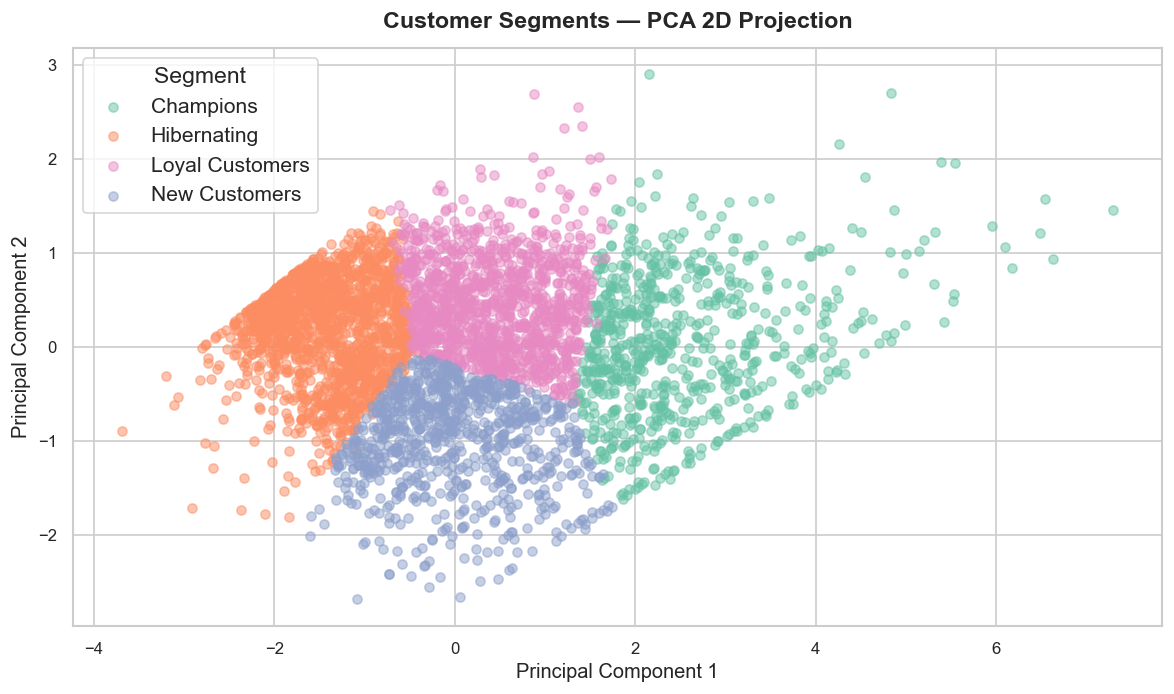

In [39]:
pca        = PCA(n_components=2, random_state=42)
rfm_pca    = pca.fit_transform(rfm_scaled)
rfm['PC1'] = rfm_pca[:, 0]
rfm['PC2'] = rfm_pca[:, 1]


print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}')
print(f'Total variance explained : {sum(pca.explained_variance_ratio_):.2%}')

palette = sns.color_palette('Set2', k)

plt.figure(figsize=(10, 6))
for cluster_id, segment_name in segments_map.items():
    mask = rfm['Cluster'] == cluster_id
    plt.scatter(
        rfm.loc[mask, 'PC1'],
        rfm.loc[mask, 'PC2'],
        label=segment_name,
        alpha=0.5,
        s=30,
        color=palette[cluster_id]
    )
plt.title('Customer Segments — PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

## Segment Analysis

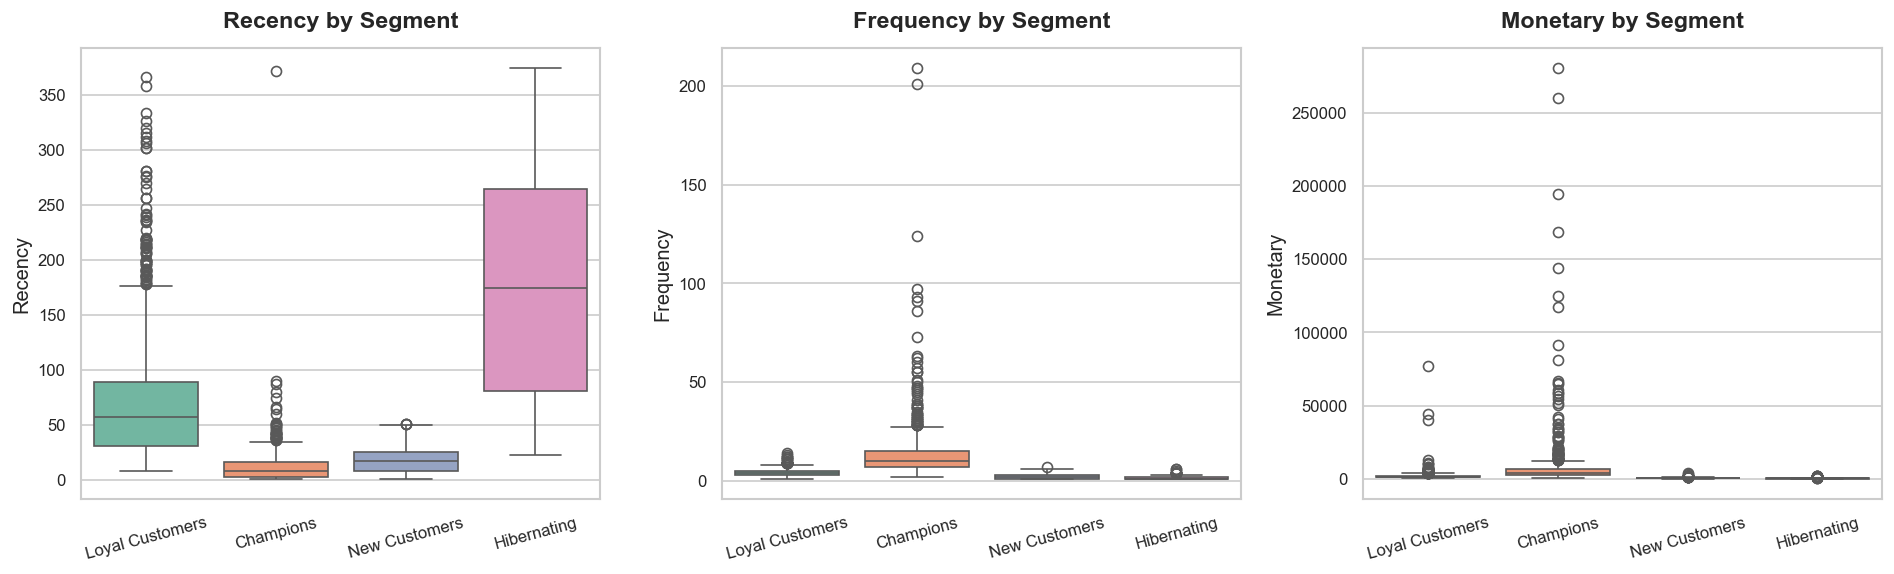

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(rfm_cols):
    sns.boxplot(
        x='Segment',
        y=col,
        data=rfm,
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f'{col} by Segment')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

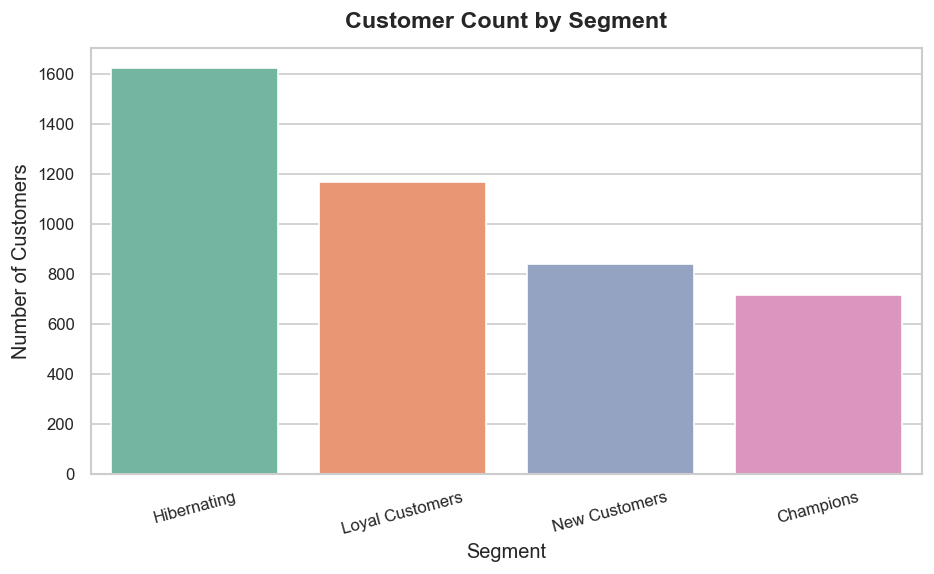

In [41]:
seg_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=seg_counts.index, y=seg_counts.values, palette='Set2')
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Revenue Contribution by Segment:
  Champions                : 64.9%
  Loyal Customers          : 23.6%
  Hibernating              : 6.2%
  New Customers            : 5.2%


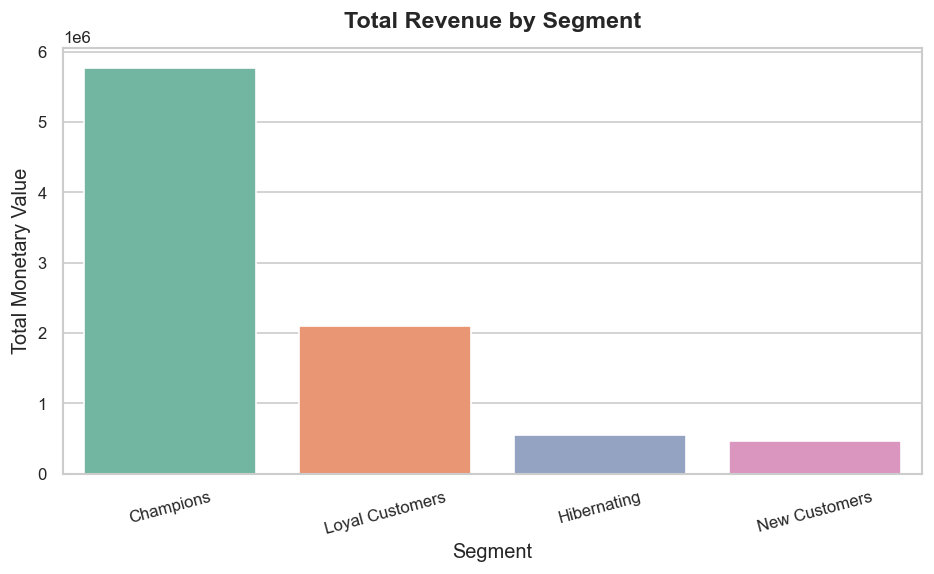

In [42]:
revenue_by_seg = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
revenue_pct    = (revenue_by_seg / revenue_by_seg.sum() * 100).round(1)

print('Revenue Contribution by Segment:')
for seg, pct in revenue_pct.items():
    print(f'  {seg:25s}: {pct:.1f}%')

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_seg.index, y=revenue_by_seg.values, palette='Set2')
plt.title('Total Revenue by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Monetary Value')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

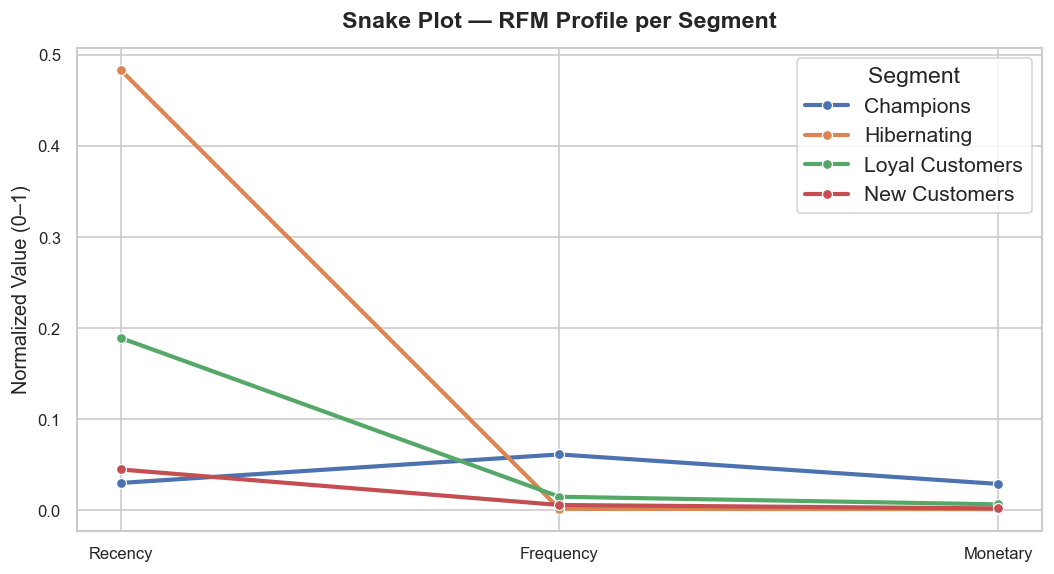

In [43]:
rfm_norm = rfm[rfm_cols].copy()
for col in rfm_cols:
    rfm_norm[col] = (rfm[col] - rfm[col].min()) / (rfm[col].max() - rfm[col].min())

rfm_norm['Segment'] = rfm['Segment']

snake = rfm_norm.groupby('Segment')[rfm_cols].mean().reset_index()
snake = snake.melt(id_vars='Segment', var_name='Metric', value_name='Value')

plt.figure(figsize=(9, 5))
sns.lineplot(x='Metric', y='Value', hue='Segment', data=snake, marker='o', linewidth=2.5)
plt.title('Snake Plot — RFM Profile per Segment')
plt.ylabel('Normalized Value (0–1)')
plt.xlabel('')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

# Customer Segmentation — Business Insights & Recommendations

**Dataset:** UCI Online Retail (UK online retailer, Dec 2010 – Dec 2011)
**Customers analysed:** 4,338 (after cleaning: removed duplicates, missing `CustomerID`, and non-positive `Quantity`/`UnitPrice`)
**Method:** RFM features → log-transform → standardize → K-Means (k = 4) → segment labelling

> **How to finalise this doc:** the qualitative signatures below are fixed by our segment
> definitions, but the exact figures depend on your run. Paste the numbers from the notebook's
> `profile` table and `rfm['Segment'].value_counts()` output into the cells marked `‹fill›`.

---

## What RFM means (quick recap)

| Signal | Definition in this project | Business reading |
|---|---|---|
| **Recency** | Days since the customer's last order (lower = more recent) | How "warm" the customer is right now |
| **Frequency** | Number of distinct invoices | How habitual / engaged they are |
| **Monetary** | Total spend (`Quantity × UnitPrice`) | How valuable they are |

A great customer has **low Recency, high Frequency, high Monetary**.

---

## Segment overview

Each segment's RFM signature is what *defines* it, so it's stable across runs. Fill in the numbers from your notebook.

| Segment | Recency | Frequency | Monetary | # Customers | % of base |
|---|---|---|---|---|---|
|  **Champions** | Low (recent) | High | **Highest** | ‹fill› | ‹fill› |
|  **Loyal Customers** | Low–Med | **High** | High | ‹fill› | ‹fill› |
|  **New Customers** | Low–Med | Low | Low–Med | ‹fill› | ‹fill› |
| **Hibernating** | **High (stale)** | Low | **Lowest** | ‹fill› | ‹fill› |

---

##  Champions — protect at all costs

**Who they are:** Your highest spenders who also buy recently and often. Small in number, large in revenue share — the classic 80/20 core.

**Why it matters:** Losing one Champion costs far more than losing many low-value customers. They are also your most credible source of referrals and reviews.

**Recommended actions:**
- **VIP / loyalty tier** — early access to new stock, free or priority shipping, a dedicated contact.
- **Ask for advocacy** — reviews, referrals, testimonials. They already love you; make it easy.
- **Personalised upsell/cross-sell** using their purchase history, not generic promos.
- **Do NOT discount reflexively** — they buy at full price; protect margin. Reward with *service and access*, not price cuts.

**KPIs to watch:** retention rate, average order value (AOV), referral conversions, share of total revenue.

---

## Loyal Customers — grow toward Champion status

**Who they are:** Frequent, engaged buyers with solid spend, but not (yet) the top monetary tier.

**Why it matters:** This is your most efficient growth pool — they already trust you; the goal is to increase *basket size*, not to re-acquire them.

**Recommended actions:**
- **Cross-sell & bundle** — "customers who bought X also bought Y"; complementary product bundles to lift AOV.
- **Tiered rewards** — show them how close they are to the next loyalty tier (Champion perks) to pull spend upward.
- **Replenishment reminders** for consumable/repeat items timed to their purchase cadence.
- **Feedback loop** — they're engaged enough to answer surveys; use them to test new ranges.

**KPIs to watch:** AOV growth, upgrade rate into Champions, purchase frequency trend.

---

##  New Customers — convert first purchase into a habit

**Who they are:** Recently acquired or low-frequency buyers who haven't yet established a pattern. High potential, unproven.

**Why it matters:** The gap between the 1st and 2nd purchase is where most customers are won or lost. A good onboarding experience here compounds for years.

**Recommended actions:**
- **Onboarding / welcome series** — thank-you email, how-to content, brand story; set the expectation of a relationship.
- **Second-purchase nudge** — a time-boxed incentive on the *next* order to trigger the repeat-buy habit.
- **Reduce friction** — proactive delivery updates, easy returns, responsive support to build early trust.
- **Recommend "starter" best-sellers** rather than the long tail — reduce choice paralysis.

**KPIs to watch:** first→second purchase conversion rate, time-to-second-order, 90-day retention.

---

##  Hibernating — win back selectively, don't overspend

**Who they are:** Customers who spent little and haven't purchased in a long time. The largest and least valuable group by revenue.

**Why it matters:** Some are genuinely gone; chasing all of them wastes budget. The opportunity is a **cheap, targeted win-back** on the subset showing any signs of life, and *learning* from the rest.

**Recommended actions:**
- **Reactivation campaign** — "we miss you" with a clear, one-time offer; keep the cost low.
- **Segment the reactivation** — prioritise those with even moderate past Monetary/Frequency; deprioritise one-time bargain hunters.
- **Cap the spend** — move non-responders to low-cost channels (occasional email) rather than paid re-acquisition.
- **Diagnose churn** — a short "why did you leave?" survey feeds product, pricing, and delivery improvements.

**KPIs to watch:** reactivation rate, cost per reactivated customer, deliverability/unsubscribe rate.

---

## Where to focus first (prioritisation)

1. **Protect Champions** — highest revenue-at-risk; cheapest to retain vs. re-acquire.
2. **Convert New Customers** — biggest long-term compounding effect; the 2nd-purchase moment is decisive.
3. **Grow Loyal Customers** — efficient AOV upside from an already-trusting base.
4. **Win back Hibernating selectively** — lowest priority per customer; run lean, learn from it.

**Guiding principle:** spend retention effort in proportion to customer value. Reward high-value segments with *access and service*; use *incentives* mainly to trigger behaviour change (2nd purchase, reactivation) where it pays back.

---

## Caveats & next steps

- **Clusters are descriptive, not causal.** They tell you *who* behaves how, not *why*. Pair with qualitative research before big bets.
- **This is a snapshot** (Dec 2010–Dec 2011). Re-score customers on a schedule (e.g. monthly) so segments stay current — a Champion can drift into Hibernating.
- **The metrics favoured k = 2**; we chose k = 4 for actionability. If segments feel blurry in practice, revisit k or add features (tenure, product category mix, geography).
- **Validate before spending:** A/B test one campaign per segment and measure lift against a hold-out before rolling out.
